# Wine Quality — Modelo Melhorado

Melhorias implementadas em relação à versão original:
- Análise exploratória e visualização da distribuição de classes
- Engenharia de features (interações e log-transformações)
- Tratamento do desbalanceamento com `class_weight='balanced'`
- Comparação entre MLP, RandomForest e GradientBoosting
- Busca de hiperparâmetros com `RandomizedSearchCV`
- Avaliação com cross-validation (5-fold)
- Serialização do pipeline final

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from scipy.stats import randint, uniform

## 1. Carregamento e EDA

In [4]:
df = pd.read_csv('../data/wine_quality_merged.csv')
print(f'Shape: {df.shape}')
display(df.head())
display(df.describe())

Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


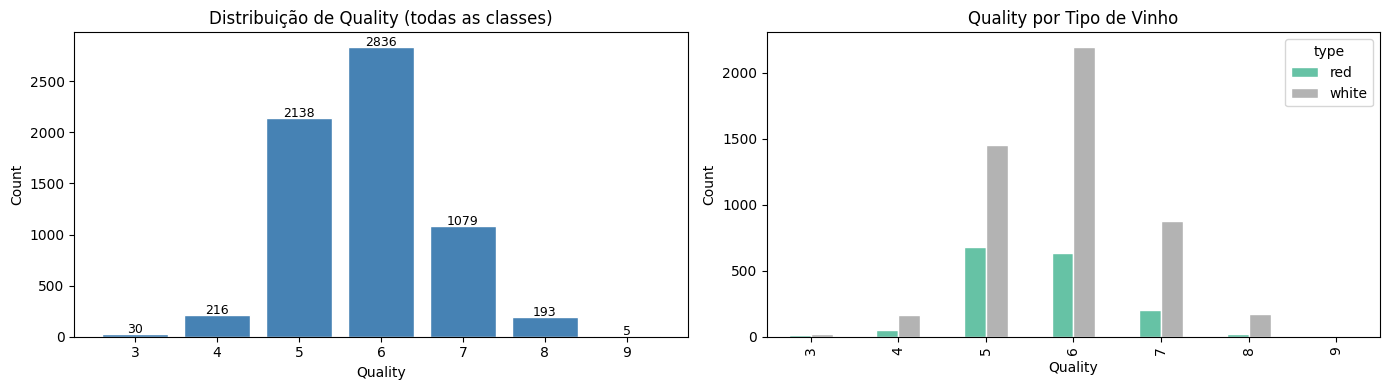

⚠️  Classes 3 e 9 são raríssimas — o modelo original zerava nelas.


In [5]:
# Distribuição de classes — problema central de desbalanceamento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vc = df['quality'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de Quality (todas as classes)')
axes[0].set_xlabel('Quality'); axes[0].set_ylabel('Count')
for x, y in zip(vc.index, vc.values):
    axes[0].text(x, y + 10, str(y), ha='center', fontsize=9)

pd.crosstab(df['type'], df['quality']).T.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Quality por Tipo de Vinho')
axes[1].set_xlabel('Quality'); axes[1].set_ylabel('Count')
axes[1].legend(title='type')

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150)
plt.show()
print('⚠️  Classes 3 e 9 são raríssimas — o modelo original zerava nelas.')

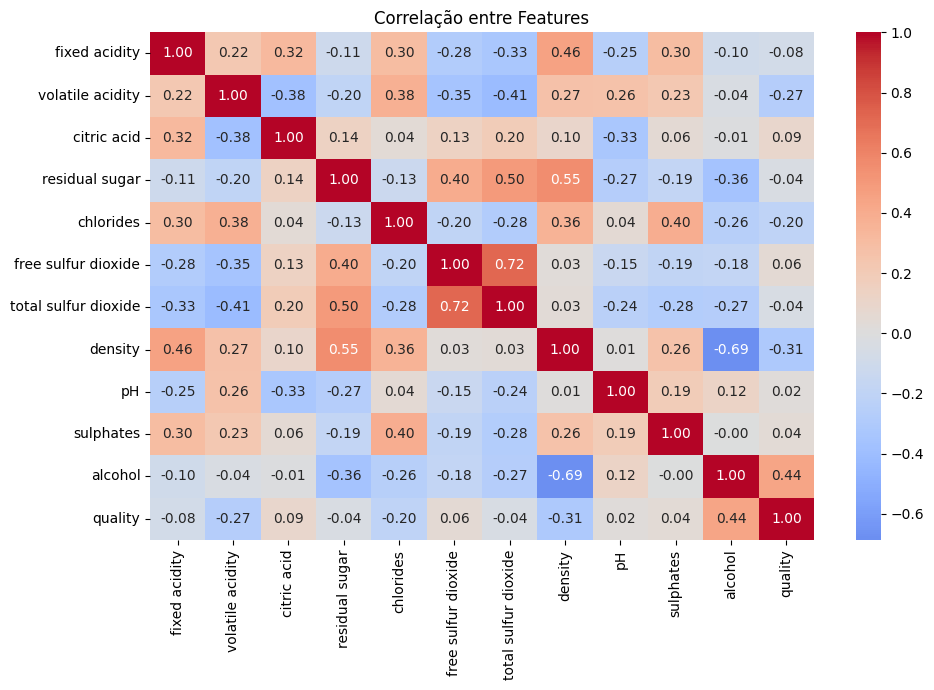

In [6]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre Features')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150)
plt.show()

## 2. Engenharia de Features

In [7]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Adiciona features derivadas sem vazar informação do target."""
    df = df.copy()
    # Interações com forte correlação observada no EDA
    df['alcohol_sulphates']     = df['alcohol'] * df['sulphates']
    df['acid_ratio']            = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
    df['so2_ratio']             = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)
    # Log-transform em features com skew elevado
    for col in ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide']:
        df[f'log_{col.replace(" ", "_")}'] = np.log1p(df[col])
    return df

df_feat = add_features(df)
print('Novas features:', [c for c in df_feat.columns if c not in df.columns])

Novas features: ['alcohol_sulphates', 'acid_ratio', 'so2_ratio', 'log_residual_sugar', 'log_chlorides', 'log_free_sulfur_dioxide', 'log_total_sulfur_dioxide']


## 3. Split Treino / Teste (estratificado)

In [8]:
X = df_feat.drop(columns=['quality'])
y = df_feat['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Treino: {X_train.shape}  |  Teste: {X_test.shape}')

Treino: (5197, 19)  |  Teste: (1300, 19)


## 4. Preprocessor Compartilhado

In [9]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## 5. Comparação de Modelos

| Modelo | Vantagem neste dataset |
|---|---|
| MLP (original) | Captura não-linearidades, mas sensível ao desbalanceamento |
| RandomForest | Robusto, `class_weight` nativo, menos tuning |
| GradientBoosting | Geralmente melhor acurácia em tabular data |

MLP (original)             CV Acc: 0.6021 ± 0.0103
MLP (balanced)             CV Acc: 0.5765 ± 0.0154
RandomForest               CV Acc: 0.6706 ± 0.0111
GradientBoosting           CV Acc: 0.6450 ± 0.0155


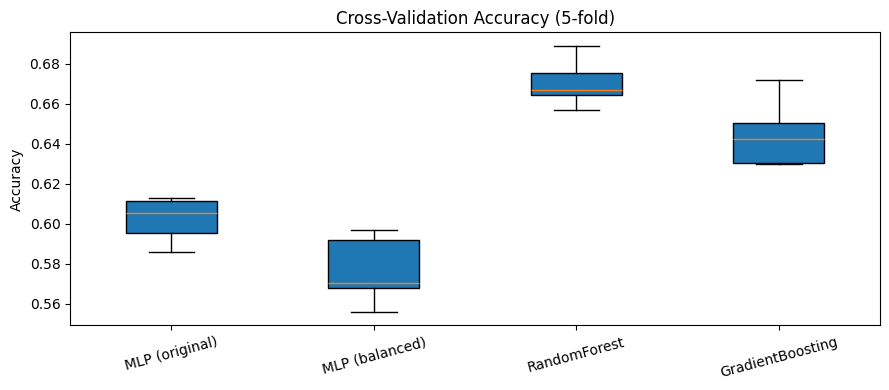

In [10]:
candidates = {
    'MLP (original)': MLPClassifier(
        hidden_layer_sizes=(200, 100), max_iter=2000, random_state=42
    ),
    'MLP (balanced)': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), max_iter=2000, random_state=42,
        early_stopping=True, validation_fraction=0.1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
    ),
}

results = {}
for name, clf in candidates.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    # 5-fold CV no treino para comparação justa
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    results[name] = cv_scores
    print(f'{name:25s}  CV Acc: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([results[k] for k in results], labels=list(results.keys()), vert=True, patch_artist=True)
ax.set_title('Cross-Validation Accuracy (5-fold)')
ax.set_ylabel('Accuracy')
ax.set_xticklabels(list(results.keys()), rotation=15)
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150)
plt.show()

## 6. Tuning do Melhor Modelo (RandomizedSearchCV)

In [11]:
# Ajuste o estimador escolhido aqui — exemplo com RandomForest
best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

param_dist = {
    'classifier__n_estimators':    randint(200, 600),
    'classifier__max_depth':       [None, 10, 20, 30],
    'classifier__min_samples_leaf': randint(1, 8),
    'classifier__max_features':    ['sqrt', 'log2', 0.5],
}

search = RandomizedSearchCV(
    best_pipe, param_dist,
    n_iter=30,           # aumente para busca mais ampla
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)
search.fit(X_train, y_train)

print('Melhores parâmetros:', search.best_params_)
print(f'Melhor CV accuracy: {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores parâmetros: {'classifier__max_depth': 30, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 513}
Melhor CV accuracy: 0.6727


## 7. Avaliação Final no Conjunto de Teste

Accuracy: 0.6923

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.42      0.12      0.18        43
           5       0.74      0.71      0.72       428
           6       0.66      0.80      0.72       567
           7       0.71      0.58      0.64       216
           8       1.00      0.33      0.50        39
           9       0.00      0.00      0.00         1

    accuracy                           0.69      1300
   macro avg       0.50      0.36      0.40      1300
weighted avg       0.69      0.69      0.68      1300



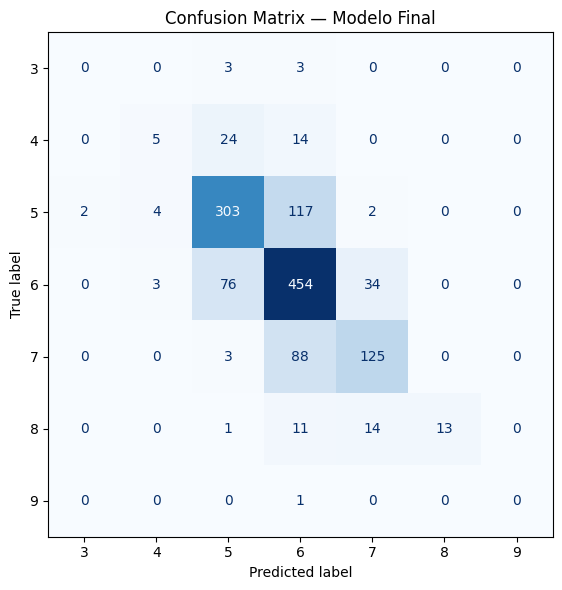

In [12]:
final_model = search.best_estimator_
y_pred = final_model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Modelo Final')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

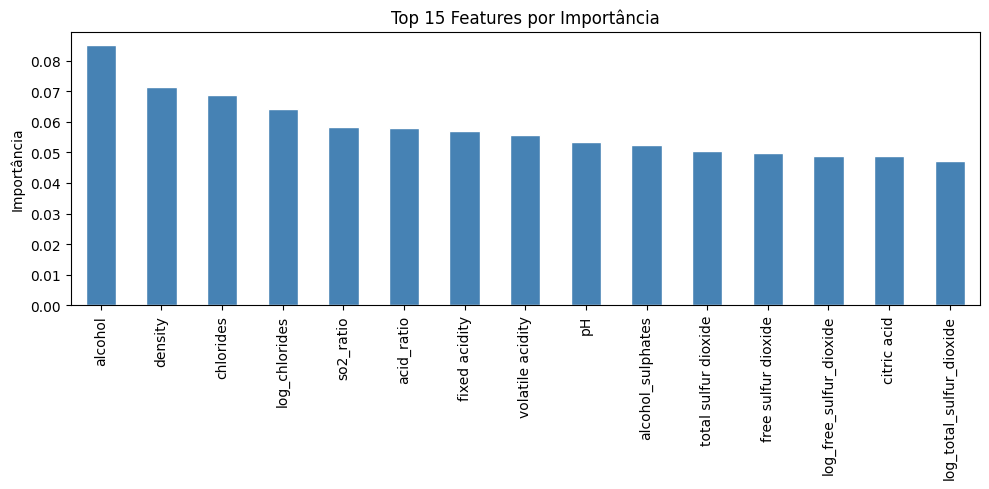

In [13]:
# Importância das features (só disponível em modelos baseados em árvore)
clf = final_model.named_steps['classifier']
if hasattr(clf, 'feature_importances_'):
    pre = final_model.named_steps['preprocessor']
    feat_names = (
        num_cols
        + list(pre.named_transformers_['cat'].get_feature_names_out(cat_cols))
    )
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    imp.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Top 15 Features por Importância')
    plt.ylabel('Importância')
    plt.tight_layout()
    plt.savefig('../reports/feature_importance.png', dpi=150)
    plt.show()

## 8. Serialização do Pipeline Final

In [14]:
model_path = '../app/mlp_wine.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)
print(f'✅ Modelo salvo em {model_path}')

# Smoke test
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)
sample = X_test.iloc[:3]
print('Predições de amostra:', loaded.predict(sample).tolist())

✅ Modelo salvo em ../app/mlp_wine.pkl
Predições de amostra: [7, 6, 5]
